# Malaria Diagnosis - DenseNet121 · Owner: **Dan Paul Dushime** (Team Lead)
### Formative 2 (Group Assignment) - Introduction to Machine Learning

This is **Dan Paul Dushime**'s notebook. As team lead I also built the shared data pipeline every model uses, and my own model is the **DenseNet121** transfer-learning network, with the seven experiments behind it. Everything from *Configuration* down to *The training engine* is the team's **shared, identical** setup so every model is judged the same way. Only the model section at the bottom is mine.

| Member | Owns | |
|---|---|---|
| **Team 17 (all)** | **Baseline CNN** | collective group model |
| Dan Paul Dushime | DenseNet121 (transfer) + data pipeline | team lead |
| Apoh Prince Eldrige | Improved CNN (deeper + augmentation) | |
| Delucie Rurangwa | VGG16 (transfer learning) | |
| Sheilla Keza Ruvugabigwi | ResNet50 (transfer learning) | |
| Serein Shima Byiringiro | MobileNetV2 (transfer learning) + report compilation | |

My seven experiments are saved to `results_DenseNet121.csv`. The baseline is a **collective group model** (`Malaria_Baseline_CNN_Group.ipynb`); for the group leaderboard, all members' `results_*.csv` files are combined in Shima's compilation notebook.

## ⚡ Notes to ourselves before running this

We learned the hard way that the free Colab GPU runs out before you can train five models seven times each, so we redesigned the notebook around that problem. A few decisions worth explaining:

- **We use all 27,558 images** (`SAMPLE_FRACTION = 1.0`). At first we were tempted to train on a smaller slice to save time, but we realised that using less data is exactly what makes a model overfit, which is the opposite of what we want. More data is the cheapest way to generalise better, so we kept all of it.
- **We switched to a `tf.data` pipeline** (`image_dataset_from_directory` with cache + prefetch). Our first version used the older `ImageDataGenerator` and it was painfully slow, the GPU was sitting idle waiting for images. Caching and prefetching keep the GPU busy, which is what made full-data training actually affordable.
- **We added EarlyStopping and ReduceLROnPlateau.** We put these in specifically to control fitting: EarlyStopping (with best-weight restore) stops training the moment the validation loss stops improving so the model can't keep memorising the training set, and ReduceLROnPlateau drops the learning rate when progress stalls so the model doesn't get stuck underfitting.
- **We made it resumable.** Each experiment's results are written to `all_experiment_results.csv` the instant it finishes, and the notebook skips anything already in that file. This way, when Colab disconnects, we just re-run everything and it carries on from where it stopped instead of throwing away hours of work. Set `USE_DRIVE_CKPT = True` to keep that file on Drive so it even survives a full runtime reset.

## 1. Why this problem matters to us

Malaria is caused by *Plasmodium* parasites spread by *Anopheles* mosquitoes, and it still kills hundreds of thousands of people a year, mostly young children. The way it is normally diagnosed is a technician looking at a stained blood smear under a microscope and counting infected cells by hand. We chose to work on this because that manual process is slow, needs a trained expert, and isn't available everywhere it's needed, which is exactly the kind of bottleneck a trained model could help with. Our objective in this notebook is to automate the "parasitized vs uninfected" decision on single-cell images.

## 2. Configuration & environment

We keep all the settings we tune in one place so we don't have magic numbers scattered through the notebook. Make sure the runtime is set to **GPU** (*Runtime → Change runtime type → GPU*), we check for it below because without a GPU the training times are not realistic.

In [1]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU:", gpus if gpus else "NONE - enable a GPU runtime!")

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ---------------- RUN SETTINGS ----------------
SAMPLE_FRACTION = 1.0      # use ALL images (full accuracy). Lower only for a quick smoke test.
MAX_EPOCHS      = 25       # upper bound; EarlyStopping usually stops earlier
PATIENCE        = 5        # EarlyStopping patience on val_loss
MIXED_PRECISION = True     # faster + less GPU memory
RESET_RESULTS   = False    # True once to wipe saved results and start over
USE_DRIVE_CKPT  = True     # ON: results CSV is saved to Google Drive so progress survives a runtime disconnect

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
MODEL_TAG   = "DenseNet121"          # this notebook's model - keep UNIQUE per member
RESULTS_CSV = f"results_{MODEL_TAG}.csv"
print(f"data={int(SAMPLE_FRACTION*100)}% | max_epochs={MAX_EPOCHS} | patience={PATIENCE} | batch={BATCH_SIZE}")

data=100% | max_epochs=25 | patience=5 | batch=32


In [3]:
import os, random, shutil, zipfile, urllib.request, time, warnings, gc
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     BatchNormalization, GlobalAveragePooling2D, Input, Rescaling,
                                     RandomFlip, RandomRotation, RandomZoom, RandomTranslation)
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K, mixed_precision
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2, DenseNet121
from tensorflow.keras.utils import image_dataset_from_directory

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
if MIXED_PRECISION and gpus:
    mixed_precision.set_global_policy('mixed_float16'); print("Mixed precision: ON")
else:
    print("Mixed precision: OFF")

Mixed precision: ON


In [4]:
# ==================== CHECKPOINT / RESUME (survives runtime disconnects) ====================
# WHY: Colab wipes the local VM when the runtime disconnects. Saving the results CSV to Google
# Drive means every FINISHED experiment is kept. On reconnect, just Run-all again: run_experiment()
# reads this CSV and SKIPS experiments already done (see _done/_save below), so you resume instead
# of starting over. Set USE_DRIVE_CKPT=False in RUN SETTINGS only if you are NOT on Colab.
if USE_DRIVE_CKPT:
    try:
        from google.colab import drive
        drive.mount('/content/drive')                       # one-time auth per session
        CKPT_DIR = '/content/drive/MyDrive/malaria_ckpt'
        os.makedirs(CKPT_DIR, exist_ok=True)
        RESULTS_CSV = os.path.join(CKPT_DIR, f'results_{MODEL_TAG}.csv')
        print('Checkpoint ON -> progress saved to:', RESULTS_CSV)
        # TIP: point CKPT_DIR at a SHARED Drive folder so the compiler can read everyone's results_*.csv
        if os.path.exists(RESULTS_CSV):
            print('   Found existing checkpoint - finished experiments will be skipped on resume.')
        else:
            print('   No checkpoint yet - a fresh one will be created as experiments finish.')
    except Exception as e:
        print('Drive mount failed (not on Colab?) - falling back to local CSV:', e)
        print('   WARNING: local CSV is lost if the runtime disconnects.')
else:
    print('Checkpoint OFF - results CSV stays on the local VM and is lost on disconnect.')


Mounted at /content/drive
Checkpoint ON -> progress saved to: /content/drive/MyDrive/malaria_ckpt/results_DenseNet121.csv
   No checkpoint yet - a fresh one will be created as experiments finish.


## 3. Dataset - downloaded straight from the NIH link

We deliberately download the dataset from the official NIH URL instead of mounting it from someone's Google Drive. We did this so that anyone in the group (or the facilitator) can run the notebook from scratch without needing access to our personal drives, it makes the work reproducible. The dataset has 27,558 single-cell images, evenly split between `Parasitized` and `Uninfected`, which is convenient because a balanced dataset means accuracy is actually a meaningful metric for us.

In [5]:
DATA_URL = "https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip"
ZIP_PATH, RAW_DIR = "cell_images.zip", "cell_images"
if not os.path.exists(RAW_DIR):
    if not os.path.exists(ZIP_PATH):
        print("Downloading from NIH (~337 MB) ..."); urllib.request.urlretrieve(DATA_URL, ZIP_PATH); print("done.")
    print("Extracting ...");
    with zipfile.ZipFile(ZIP_PATH,"r") as z: z.extractall(".")
    print("done.")
else:
    print("Dataset already present.")
if os.path.isdir(os.path.join(RAW_DIR,"cell_images")): RAW_DIR = os.path.join(RAW_DIR,"cell_images")
for c in ["Parasitized","Uninfected"]:
    print(f"  {c}: {len(os.listdir(os.path.join(RAW_DIR,c)))} images")

done.
Extracting ...
done.
  Parasitized: 13780 images
  Uninfected: 13780 images


### 3.1 Splitting the data 70/15/15

We split the images once into training, validation and test sets and then reuse that exact same split for every model. We thought about letting each model make its own split, but then any difference in results could just be down to luck in the split rather than the model itself. Fixing the split (and the random seed) means that when VGG16 beats the baseline, we can actually attribute that to the model. We use 70% for training, 15% to tune and watch for overfitting, and a final 15% that we never touch until the end.

In [6]:
BASE = "dataset"
if not os.path.exists(BASE):
    for split in ["train","val","test"]:
        for c in ["Parasitized","Uninfected"]:
            os.makedirs(os.path.join(BASE,split,c), exist_ok=True)
    for c in ["Parasitized","Uninfected"]:
        files = [f for f in os.listdir(os.path.join(RAW_DIR,c)) if f.lower().endswith(".png")]
        random.shuffle(files)
        if SAMPLE_FRACTION < 1.0: files = files[:int(len(files)*SAMPLE_FRACTION)]
        n=len(files); ntr=int(n*0.70); nva=int(n*0.15)
        for split,fl in {"train":files[:ntr],"val":files[ntr:ntr+nva],"test":files[ntr+nva:]}.items():
            for f in fl: shutil.copy(os.path.join(RAW_DIR,c,f), os.path.join(BASE,split,c,f))
    print("Split created.")
else:
    print("Split exists (delete the 'dataset' folder to rebuild).")
for split in ["train","val","test"]:
    print(split, {c: len(os.listdir(os.path.join(BASE,split,c))) for c in ["Parasitized","Uninfected"]})

Split created.
train {'Parasitized': 9645, 'Uninfected': 9645}
val {'Parasitized': 2066, 'Uninfected': 2066}
test {'Parasitized': 2068, 'Uninfected': 2068}


### 3.2 The input pipeline (built once and shared)

This was our biggest performance fix. We build the train/validation/test datasets a single time and reuse them across all 42 experiments, instead of rebuilding a slow generator every run. We `cache()` so the images only get read and decoded from disk once, and `prefetch()` so the next batch is being prepared on the CPU while the GPU trains on the current one. We also keep the class order fixed and leave the test set unshuffled, otherwise our predictions wouldn't line up with the true labels when we score them.

In [7]:
AUTOTUNE = tf.data.AUTOTUNE
CLASS_NAMES = ["Uninfected","Parasitized"]
def _ds(split, shuffle):
    return image_dataset_from_directory(os.path.join(BASE,split), labels="inferred", label_mode="binary",
        class_names=["Uninfected","Parasitized"], image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        shuffle=shuffle, seed=SEED)
train_ds_raw = _ds("train", True)
val_ds_raw   = _ds("val",   False)
test_ds_raw  = _ds("test",  False)

# y_true for the test set (order preserved because shuffle=False)
y_test = np.concatenate([y.numpy() for _,y in test_ds_raw]).ravel().astype(int)

train_ds = train_ds_raw.cache().prefetch(AUTOTUNE)
val_ds   = val_ds_raw.cache().prefetch(AUTOTUNE)
test_ds  = test_ds_raw.cache().prefetch(AUTOTUNE)
print("Pipeline ready. Test labels:", np.bincount(y_test))

Found 19290 files belonging to 2 classes.
Found 4132 files belonging to 2 classes.
Found 4136 files belonging to 2 classes.
Pipeline ready. Test labels: [2068 2068]


## 4. The training engine (shared so every model is judged the same way)

We wrote one training/evaluation function that every member's model goes through, because if we each scored our own model our own way the comparison would be meaningless. A couple of choices we made here on purpose:

- **Augmentation and preprocessing are baked into the model as layers.** We flip, rotate, zoom and shift the training images so the model sees more variety and is less likely to memorise specific cells. We put the backbone-specific preprocessing in as a layer too, so each pretrained model gets the exact input format it was originally trained on.
- **EarlyStopping + ReduceLROnPlateau on every run.** These are our main tools against over- and underfitting, so we apply them everywhere rather than per-model.
- **We log a `train_acc`, `val_acc` and `overfit_gap`** for every experiment. We added the gap column specifically so we have hard evidence for the overfitting discussion in the report instead of just eyeballing the curves.
- **`plot_best` retrains only the best configuration** of a model to draw its plots. We did it this way so the diagnostic plots still appear even after a disconnect, without paying to retrain all seven runs.

In [8]:
# Augmentation pipeline (active only during training) and per-backbone preprocessing
data_augment = Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.10),
    RandomZoom(0.10),
    RandomTranslation(0.10, 0.10),
], name="augment")

from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_pre
from tensorflow.keras.applications.densenet import preprocess_input as densenet_pre
BACKBONES = {"VGG16":(VGG16,vgg_pre), "ResNet50":(ResNet50,resnet_pre), "MobileNetV2":(MobileNetV2,mobilenet_pre), "DenseNet121":(DenseNet121,densenet_pre)}

def _stem(cfg, inp):
    """Augment (if requested) then apply the right preprocessing as layers."""
    x = data_augment(inp) if cfg.get("augment") else inp
    if cfg.get("backbone"):
        x = layers.Lambda(BACKBONES[cfg["backbone"]][1])(x)
    else:
        x = Rescaling(1./255)(x)
    return x

def out_dense(x):
    return Dense(1, activation="sigmoid", dtype="float32")(x)

In [9]:
def build_transfer(cfg, input_shape):
    BackboneCls,_ = BACKBONES[cfg["backbone"]]
    base = BackboneCls(include_top=False, weights="imagenet", input_shape=input_shape)
    base.trainable = cfg["fine_tune"]
    if cfg["fine_tune"] and cfg.get("unfreeze_from") is not None:
        for layer in base.layers[:cfg["unfreeze_from"]]: layer.trainable = False
    inp = Input(input_shape); x = _stem(cfg, inp)
    x = base(x, training=cfg["fine_tune"])
    x = GlobalAveragePooling2D()(x); x = Dropout(cfg["dropout"])(x)
    x = Dense(cfg["dense"], activation="relu")(x); x = Dropout(cfg["dropout"])(x)
    return Model(inp, out_dense(x))

In [10]:
RESULTS = []
if RESET_RESULTS and os.path.exists(RESULTS_CSV): os.remove(RESULTS_CSV); print("Results reset.")
if os.path.exists(RESULTS_CSV):
    RESULTS = pd.read_csv(RESULTS_CSV).to_dict("records")
    print(f"Resumed {len(RESULTS)} finished experiment(s).")
else:
    print("No previous results - starting fresh.")

def _done(model_name, exp_id):
    return any(r["model"]==model_name and r["experiment"]==exp_id for r in RESULTS)
def _save(): pd.DataFrame(RESULTS).to_csv(RESULTS_CSV, index=False)

def evaluate(model):
    y_prob = model.predict(test_ds, verbose=0).ravel().astype("float32")
    y_pred = (y_prob>=0.5).astype(int)
    return {"accuracy":accuracy_score(y_test,y_pred), "precision":precision_score(y_test,y_pred,zero_division=0),
            "recall":recall_score(y_test,y_pred,zero_division=0), "f1":f1_score(y_test,y_pred,zero_division=0),
            "y_prob":y_prob, "y_pred":y_pred}

def _train(cfg):
    K.clear_session(); gc.collect()
    model = cfg["build_fn"](cfg, IMG_SIZE+(3,))
    model.compile(optimizer=cfg["opt"](), loss="binary_crossentropy", metrics=["accuracy"])
    cbs = [EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
           ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6, verbose=0)]
    t0=time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=min(cfg["epochs"],MAX_EPOCHS), callbacks=cbs, verbose=0)
    return model, hist, evaluate(model), round(time.time()-t0,1)

def run_experiment(owner, model_name, cfg):
    if _done(model_name, cfg["name"]):
        print(f"[{model_name}] {cfg['name']}: already done - skipped"); return
    model, hist, m, secs = _train(cfg)
    tr_acc = float(hist.history["accuracy"][-1]); va_acc = float(hist.history["val_accuracy"][-1])
    RESULTS.append({"owner":owner,"model":model_name,"experiment":cfg["name"],"config":cfg["desc"],
        "accuracy":round(m["accuracy"],4),"precision":round(m["precision"],4),"recall":round(m["recall"],4),
        "f1":round(m["f1"],4),"train_acc":round(tr_acc,4),"val_acc":round(va_acc,4),
        "overfit_gap":round(tr_acc-va_acc,4),"epochs_run":len(hist.history["loss"]),"train_sec":secs})
    _save()
    print(f"[{model_name}] {cfg['name']}: acc={m['accuracy']:.4f} f1={m['f1']:.4f} gap={tr_acc-va_acc:+.3f} (saved)")
    del model; K.clear_session(); gc.collect()

def results_table(model_name):
    df = pd.DataFrame([r for r in RESULTS if r["model"]==model_name])
    cols=["experiment","config","accuracy","precision","recall","f1","train_acc","val_acc","overfit_gap","epochs_run","train_sec"]
    return df[[c for c in cols if c in df.columns]]

def plot_best(model_name, exps):
    rows=[r for r in RESULTS if r["model"]==model_name]
    if not rows: print("No results yet for", model_name); return
    best=max(rows, key=lambda r:r["f1"])
    cfg=next(e for e in exps if e["name"]==best["experiment"])
    print(f"Retraining best config of {model_name} for plots: {cfg['name']}")
    model,hist,m,_=_train(cfg)
    fig,ax=plt.subplots(1,4,figsize=(22,4.5))
    ax[0].plot(hist.history["loss"],label="train"); ax[0].plot(hist.history["val_loss"],label="val")
    ax[0].set_title(f"{model_name} - Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(hist.history["accuracy"],label="train"); ax[1].plot(hist.history["val_accuracy"],label="val")
    ax[1].set_title(f"{model_name} - Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
    cm=confusion_matrix(y_test, m["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Uninfected","Parasitized"]).plot(ax=ax[2], colorbar=False)
    ax[2].set_title(f"{model_name} - Confusion matrix")
    fpr,tpr,_=roc_curve(y_test, m["y_prob"]); roc_auc=auc(fpr,tpr)
    ax[3].plot(fpr,tpr,label=f"AUC = {roc_auc:.3f}"); ax[3].plot([0,1],[0,1],"k--")
    ax[3].set_title(f"{model_name} - ROC"); ax[3].set_xlabel("FPR"); ax[3].set_ylabel("TPR"); ax[3].legend()
    plt.tight_layout(); plt.show()
    print(f"Best F1={best['f1']:.4f} | AUC={roc_auc:.4f} | train-val gap={best.get('overfit_gap')}")
    del model; K.clear_session(); gc.collect(); return roc_auc

No previous results - starting fresh.


## 7. Transfer-learning models (VGG16, ResNet50, MobileNetV2, DenseNet121)

For the four pretrained models we reuse the same recipe: take a network already trained on ImageNet, throw away its classification top, and put our own small head on it (`GlobalAveragePooling -> Dropout -> Dense -> sigmoid`). The reason transfer learning makes sense here is that a model trained on millions of images has already learned generic things like edges and textures, and the parasites in our cells are basically distinctive textures, so we get a head start instead of learning everything from scratch on a comparatively small medical dataset.

We chose these four backbones on purpose because they cover a range: VGG16 is big and simple, ResNet50 is deep with skip connections, MobileNetV2 is lightweight and made for low-power devices, and DenseNet121 reuses features through dense connectivity. That spread lets us talk about the accuracy-versus-cost trade-off, which matters because a model meant for a clinic has to be both accurate and affordable to run.

In [11]:
def transfer_exps(backbone):
    base=dict(backbone=backbone, build_fn=build_transfer)
    return [
     {**base,"name":"E1 frozen lr1e-3","desc":f"{backbone} frozen, LR 1e-3","fine_tune":False,"unfreeze_from":None,"dense":128,"dropout":0.3,"epochs":15,"augment":False,"opt":lambda:Adam(1e-3)},
     {**base,"name":"E2 frozen +Aug","desc":f"{backbone} frozen + aug","fine_tune":False,"unfreeze_from":None,"dense":128,"dropout":0.3,"epochs":18,"augment":True,"opt":lambda:Adam(1e-3)},
     {**base,"name":"E3 frozen drop0.5","desc":f"{backbone} frozen, dropout 0.5, dense 256","fine_tune":False,"unfreeze_from":None,"dense":256,"dropout":0.5,"epochs":18,"augment":True,"opt":lambda:Adam(1e-3)},
     {**base,"name":"E4 fine-tune lr1e-4","desc":f"{backbone} fine-tune last 30, LR 1e-4","fine_tune":True,"unfreeze_from":-30,"dense":128,"dropout":0.4,"epochs":18,"augment":True,"opt":lambda:Adam(1e-4)},
     {**base,"name":"E5 fine-tune lr1e-5","desc":f"{backbone} fine-tune last 30, LR 1e-5","fine_tune":True,"unfreeze_from":-30,"dense":128,"dropout":0.4,"epochs":20,"augment":True,"opt":lambda:Adam(1e-5)},
     {**base,"name":"E6 fine-tune unf50","desc":f"{backbone} fine-tune last 50, LR 1e-5","fine_tune":True,"unfreeze_from":-50,"dense":256,"dropout":0.5,"epochs":20,"augment":True,"opt":lambda:Adam(1e-5)},
     {**base,"name":"E7 fine-tune wide256","desc":f"{backbone} fine-tune, wider 256","fine_tune":True,"unfreeze_from":-30,"dense":256,"dropout":0.5,"epochs":22,"augment":True,"opt":lambda:Adam(1e-5)},
    ]

### Model - DenseNet121 · Owner: **Dan Paul Dushime** (Team Lead)

My name is Dan Paul Dushime. Alongside leading the team and building the shared data pipeline, I own the DenseNet121 transfer-learning model. I chose DenseNet because it takes a different structural idea from the other backbones: instead of ResNet's additive skip connections, every layer is connected to every later layer, so features are reused throughout the network. I wanted to test whether that dense feature reuse buys us accuracy on the parasite textures without the parameter blow-up of a network like VGG16.

I structured my seven experiments the same way the rest of the transfer team did, moving from a frozen feature-extractor through progressively deeper fine-tuning, with augmentation and dropout introduced along the way, so my results sit on exactly the same footing as everyone else's. Because I built the pipeline the whole group depends on, keeping my own model on that identical setup mattered to me as a fairness check as much as a personal result.

In [12]:
dense_exps=transfer_exps("DenseNet121")
for e in dense_exps: run_experiment("Dan Paul Dushime","DenseNet121", e)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[DenseNet121] E1 frozen lr1e-3: acc=0.9311 f1=0.9299 gap=-0.029 (saved)
[DenseNet121] E2 frozen +Aug: acc=0.9103 f1=0.9056 gap=-0.011 (saved)
[DenseNet121] E3 frozen drop0.5: acc=0.8980 f1=0.8921 gap=-0.041 (saved)
[DenseNet121] E4 fine-tune lr1e-4: acc=0.9616 f1=0.9613 gap=-0.005 (saved)
[DenseNet121] E5 fine-tune lr1e-5: acc=0.9480 f1=0.9473 gap=-0.017 (saved)
[DenseNet121] E6 fine-tune unf50: acc=0.9497 f1=0.9493 gap=-0.017 (saved)
[DenseNet121] E7 fine-tune wide256: acc=0.9475 f1=0.9462 gap=-0.014 (saved)


In [13]:
results_table("DenseNet121")

,experiment,config,accuracy,precision,recall,f1,train_acc,val_acc,overfit_gap,epochs_run,train_sec
0,E1 frozen lr1e-3,"DenseNet121 frozen, LR 1e-3",0.9311,0.9464,0.9139,0.9299,0.9148,0.9434,-0.0286,15,427.4
1,E2 frozen +Aug,DenseNet121 frozen + aug,0.9103,0.9559,0.8603,0.9056,0.8971,0.9080,-0.0109,18,759.2
2,E3 frozen drop0.5,"DenseNet121 frozen, dropout 0.5, dense 256",0.8980,0.9463,0.8438,0.8921,0.8663,0.9078,-0.0415,18,746.0
3,E4 fine-tune lr1e-4,"DenseNet121 fine-tune last 30, LR 1e-4",0.9616,0.9686,0.9541,0.9613,0.9593,0.9644,-0.0052,18,838.5
4,E5 fine-tune lr1e-5,"DenseNet121 fine-tune last 30, LR 1e-5",0.9480,0.9612,0.9338,0.9473,0.9380,0.9552,-0.0172,20,918.1
5,E6 fine-tune unf50,"DenseNet121 fine-tune last 50, LR 1e-5",0.9497,0.9563,0.9425,0.9493,0.9350,0.9518,-0.0168,20,976.3
6,E7 fine-tune wide256,"DenseNet121 fine-tune, wider 256",0.9475,0.9705,0.9231,0.9462,0.9375,0.9516,-0.0141,22,1008.0


Retraining best config of DenseNet121 for plots: E4 fine-tune lr1e-4


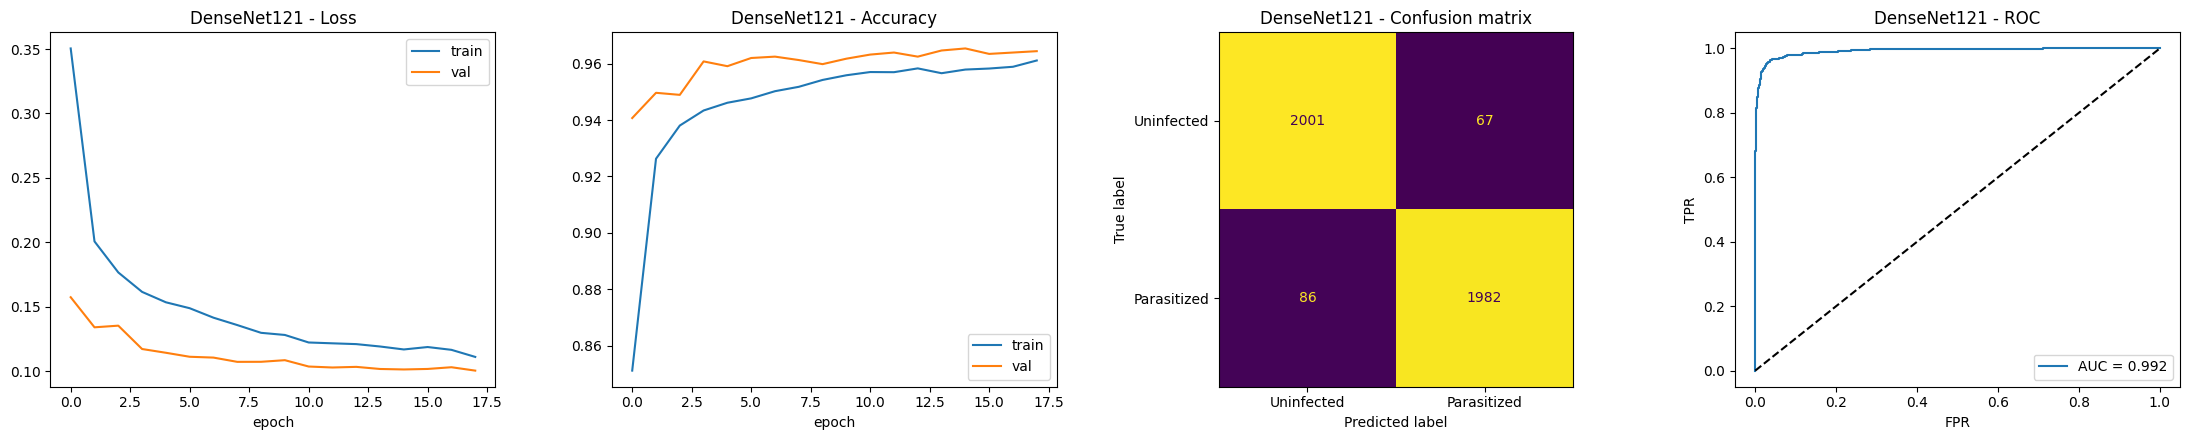

Best F1=0.9613 | AUC=0.9921 | train-val gap=-0.0052


np.float64(0.9921073257784645)

In [14]:
plot_best("DenseNet121", dense_exps)